# Linear inverse reinforcement learning for mean-field games
## Malware spread example

This notebook illustrates the finite-dimensional linear inverse reinforcement
learning formulation for stationary mean-field games under an average-reward
criterion. It should be viewed as a numerical implementation of the finite-dimensional
theory developed in our paper [[1]](#ref1), specialized to a two-state malware
spread model adapted from [[2]](#ref2). A copy of the implemented paper [[1]](#ref1) is also included in the repository assets for reference.

The goal is to show, on a simple malware spread example, how the linear
maximum-causal-entropy inverse problem can be implemented numerically. In
particular, we:

1. compute an expert stationary mean-field equilibrium $(\pi_E,\mu_E)$,
2. form the corresponding expert feature expectation vector $\langle \varphi \rangle_{\pi_E,\mu_E}$,
3. solve the dual inverse problem,
4. recover a policy that matches the expert behaviour.

Thus, the notebook provides a concrete numerical realization of the theory in
[[1]](#ref1), using the malware model dynamics motivated by [[2]](#ref2).

This notebook focuses only on the finite-dimensional linear case.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src.linear_malware import (
    solve_forward_mfe,
    occupation_measure_from_mu_pi,
    feature_expectation_from_nu,
    solve_linear_dual_irl,
    plot_dual_objective,
    plot_policy_evolution,
)

## 1. Malware spread model

We consider a stationary mean-field game with state space
$\mathcal X = \{0,1\}$ and action space $\mathcal A = \{0,1\}$.

The interpretation is:
- state $0$: healthy,
- state $1$: infected,
- action $0$: do nothing,
- action $1$: repair.

The controlled dynamics are
$$
x_{t+1} =
\begin{cases}
x_t + (1-x_t) w_t, & \text{if } a_t = 0,\\
0, & \text{if } a_t = 1,
\end{cases}
\qquad
w_t \sim \mathrm{Bernoulli}(q).
$$

Thus, if the agent does nothing, an infected agent remains infected, while a
healthy agent becomes infected with probability $q$. If the agent repairs, the
next state is reset to $0$.

The one-stage objective is described through the linear model
$$
r(x,a,\mu) = \theta_1 x + \theta_2 x \mu(1) + \theta_3 a.
$$
Equivalently, one may view this as a cost model with opposite sign. The term
$\mu(1)$ denotes the fraction of infected agents in the population, so the model
captures both individual infection cost and interaction with the aggregate state.

In [2]:
q = 0.9
theta = np.array([-2.0, -2.0, -3.0])

mu0 = np.random.dirichlet(np.ones(2))

print("q =", q)
print("theta =", theta)
print("initial guess mu0 =", mu0)

q = 0.9
theta = [-2. -2. -3.]
initial guess mu0 = [0.49842523 0.50157477]


## 2. Forward mean-field equilibrium

Before solving the inverse problem, we first generate expert behaviour by solving
the forward stationary mean-field game.

For a fixed mean-field term $\mu$, the representative agent faces an average-reward
control problem. A stationary mean-field equilibrium is a pair $(\pi,\mu)$ such
that:

- $\pi$ is optimal for the frozen mean-field term $\mu$,
- $\mu$ is invariant under the controlled dynamics induced by $\pi$.

In the notebook, this is computed by combining:
1. a solver for the frozen average-reward control problem,
2. a fixed-point update for the invariant distribution.

The resulting pair $(\pi_E,\mu_E)$ plays the role of the expert equilibrium in
the inverse problem.

In [3]:
forward_results = solve_forward_mfe(
    mu0=mu0,
    theta=theta,
    q=q,
    verbose=False,
)

mu_E = forward_results["mu_E"]
pi_E = forward_results["pi_E"]

print("Expert mean-field term mu_E =")
print(mu_E)
print()

print("Expert policy pi_E =")
print(pi_E)

Expert mean-field term mu_E =
[0.52631579 0.47368421]

Expert policy pi_E =
[[1. 0.]
 [0. 1.]]


## 3. Expert statistics and occupation measures

In the stationary setting, the expert behaviour is summarized by its occupation
measure
$$
\nu_{\pi_E}(x,a) = \mu_E(x)\pi_E(a \mid x).
$$

This is the long-run state-action frequency under the expert equilibrium. It is
the key object in the paper because it converts long-run constraints into static
linear constraints.

In the linear malware formulation, the feature map is
$$
\varphi(x,a,\mu) = \bigl(x,\; x\mu(1),\; a\bigr).
$$
The corresponding expert feature expectation is
$$
\langle \varphi \rangle_{\pi_E,\mu_E}
=
\sum_{(x,a)\in \mathcal X \times \mathcal A}
\varphi(x,a,\mu_E)\,\nu_{\pi_E}(x,a).
$$

The inverse problem will search for a policy whose long-run statistics match
these expert statistics while maximizing causal entropy.

In [4]:
nu_E = occupation_measure_from_mu_pi(mu_E, pi_E)
phi_exp_E = feature_expectation_from_nu(nu_E, mu_E)

print("Expert occupation measure nu_E =")
print(nu_E)
print()

print("Expert feature expectation vector =")
print(phi_exp_E)

Expert occupation measure nu_E =
[[0.52631579 0.        ]
 [0.         0.47368421]]

Expert feature expectation vector =
[0.47368421 0.22437673 0.47368421]


## 4. Maximum causal entropy inverse problem

In inverse reinforcement learning, the reward is not observed directly. Instead,
we observe expert behaviour and search for a policy that explains it.

Because multiple policies may satisfy the same statistical constraints, we use the maximum causal entropy principle: among all feasible policies, choose
the one with the largest causal entropy. This selects the least biased policy
consistent with the expert data.

In the linear case, the original policy-space problem can be rewritten as a
convex optimization problem over occupation measures. The constraints enforce:

- feature matching,
- flow balance,
- consistency with the expert mean-field term.

This occupation-measure reformulation is the basis of the dual numerical method
implemented below.

## 5. Dual formulation

The occupation-measure problem admits a dual formulation in the variables
$(\alpha,\beta,\theta)$. The dual objective has log-partition form:
$$
h(\alpha,\beta,\theta)
=
\log \sum_{(x,a)\in \mathcal X \times \mathcal A}
e^{\ell_{\alpha,\beta,\theta}(x,a)}
-
\langle \alpha,\langle \varphi \rangle_{\pi_E,\mu_E}\rangle
-
\sum_{x\in\mathcal X}\theta_x \mu_E(x),
$$
where
$$
\ell_{\alpha,\beta,\theta}(x,a)
=
\log \mu_E(x)
+
\langle \alpha,\varphi(x,a,\mu_E)\rangle
+
\theta_x
+
\sum_{z\in\mathcal X}
\beta_z \bigl(p(z\mid x,a,\mu_E)-\mu_E(z)\bigr).
$$

For fixed dual variables, the associated occupation measure is the Boltzmann form
$$
\nu_{\alpha,\beta,\theta}(x,a)
\propto
e^{\ell_{\alpha,\beta,\theta}(x,a)}.
$$

Thus, solving the inverse problem reduces to minimizing $h$ and then reconstructing
the policy from the recovered occupation measure.

## 6. Policy recovery

Once the dual problem is solved, we obtain a recovered occupation measure
$\nu^\star$. From this we reconstruct the policy by normalizing with respect to
its state marginal:
$$
\pi_{\nu^\star}(a \mid x)
=
\frac{\nu^\star(x,a)}{\sum_{b\in\mathcal A}\nu^\star(x,b)}.
$$

This is the cleanest way to obtain a valid stochastic policy at every iteration.
At the optimum, the recovered occupation measure should also satisfy the marginal
consistency condition with the expert mean-field term, so the recovered policy is
expected to be close to the expert equilibrium policy $\pi_E$.

In [5]:
dual_results = solve_linear_dual_irl(
    mu_E=mu_E,
    pi_E=pi_E,
    phi_exp_E=phi_exp_E,
    q=q,
    step_size=0.5,
    n_iter=100000,
    verbose=False,
)

nu_rec = dual_results["nu_rec"]
pi_rec = dual_results["pi_rec"]

print("Recovered occupation measure nu_rec =")
print(nu_rec)
print()

print("Recovered policy pi_rec =")
print(pi_rec)

Recovered occupation measure nu_rec =
[[0.52035179 0.00597038]
 [0.00557325 0.46810458]]

Recovered policy pi_rec =
[[0.98865642 0.01134358]
 [0.01176592 0.98823408]]


 ## 7. What we expect numerically

For this malware model, the expert equilibrium should have a simple qualitative
structure:

- in the healthy state, the preferred action is to do nothing,
- in the infected state, the preferred action is to repair.

Therefore, after solving the dual inverse problem, we expect the recovered policy
to place probability close to one on:
$$
\pi(0 \mid 0) \approx 1,
\qquad
\pi(1 \mid 1) \approx 1.
$$

The plots below track two aspects of the algorithm:
1. the evolution of the dual objective $h$,
2. the evolution of the recovered policy entries over the iterations.

In [6]:
print("Expert policy pi_E =")
print(pi_E)
print()

print("Recovered policy pi_rec =")
print(pi_rec)
print()

print("Difference (pi_rec - pi_E) =")
print(pi_rec - pi_E)
print()

print("Recovered state marginal from nu_rec =")
print(np.sum(nu_rec, axis=1))
print()

print("Difference from mu_E =")
print(np.sum(nu_rec, axis=1) - mu_E)

Expert policy pi_E =
[[1. 0.]
 [0. 1.]]

Recovered policy pi_rec =
[[0.98865642 0.01134358]
 [0.01176592 0.98823408]]

Difference (pi_rec - pi_E) =
[[-0.01134358  0.01134358]
 [ 0.01176592 -0.01176592]]

Recovered state marginal from nu_rec =
[0.52632217 0.47367783]

Difference from mu_E =
[ 6.37962901e-06 -6.37962901e-06]


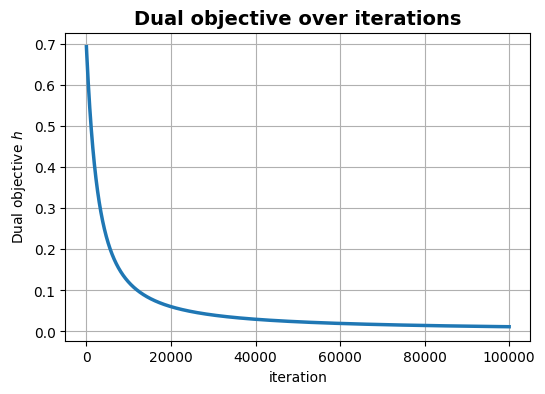

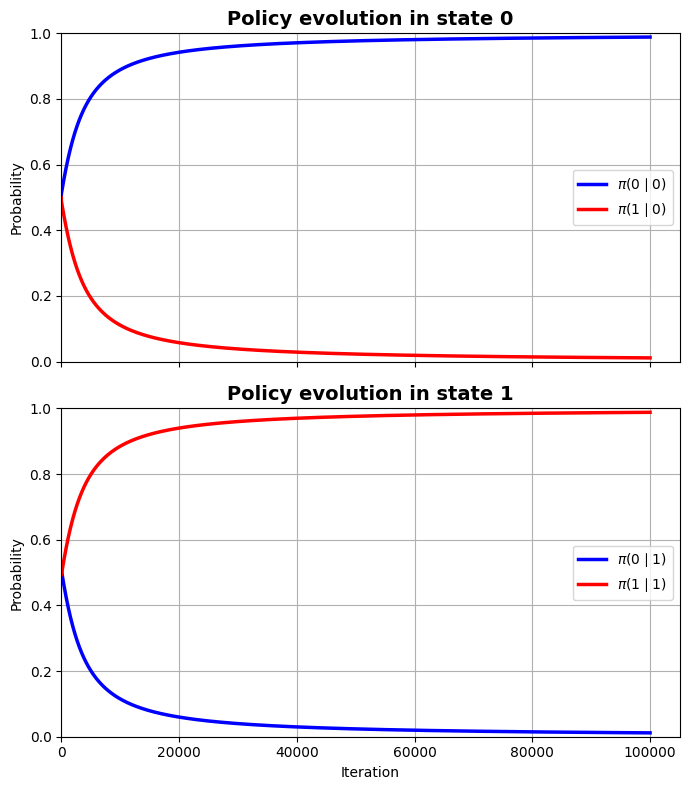

In [7]:
plot_dual_objective(dual_results)
plt.show()

plot_policy_evolution(dual_results)
plt.show()

## 9. Summary

This notebook implements the linear average-reward inverse reinforcement learning
framework for a stationary mean-field game with a two-state malware spread model.

The numerical experiment shows how the occupation-measure and dual formulations
from the paper lead to a practical recovery method. The recovered policy should
closely match the expert equilibrium and reproduce the same qualitative decision
structure.

In [8]:
print("Final summary")
print("-------------")
print("mu_E =", mu_E)
print("pi_E =\n", pi_E)
print("pi_rec =\n", pi_rec)
print("final dual objective =", dual_results["final_h"])
print("final gradient norm =", dual_results["final_grad_norm"])
print("final marginal error =", dual_results["final_marginal_error"])

Final summary
-------------
mu_E = [0.52631579 0.47368421]
pi_E =
 [[1. 0.]
 [0. 1.]]
pi_rec =
 [[0.98865642 0.01134358]
 [0.01176592 0.98823408]]
final dual objective = 0.011610803072261144
final gradient norm = 0.00048723788710483703
final marginal error = 1.275925802529665e-05


## References

<a id="ref1"></a>
[1] Ş. K. Alkır and N. Saldı, “Inverse Reinforcement Learning for Mean-field Games with Average Reward Criterion,” *2025 IEEE 64th Conference on Decision and Control (CDC)*, pp. 7272–7277, 2025.

<a id="ref2"></a>
[2] J. Subramanian and A. Mahajan, “Reinforcement learning in stationary mean-field games,” *Proceedings of the 18th International Conference on Autonomous Agents and MultiAgent Systems (AAMAS)*, 2019.